In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def line_id_color(line_id, T, cm):
    if line_id < 0:
        return 'red' 
    return cm(line_id / T)

def visualize_confidence(results):
    if results is None:
        print("No corridor results to visualize.")
        return
    
    max_len = max(len(r["confidence"]) for r in results)
    C = np.full((len(results), max_len), np.nan)

    for i, r in enumerate(results):
        C[i, :len(r["confidence"])] = r["confidence"]

    plt.figure(figsize=(16, 16))
    plt.imshow(C, aspect="auto", cmap="inferno")
    plt.colorbar(label="confidence")
    plt.xlabel("pseudotime")
    plt.ylabel("corridor")
    plt.title("Confidence heatmap")
    plt.show()

def visualize_template(template):
    if template is None:
        print("No template to visualize.")
        return
    plt.figure(figsize=(8, 3))
    plt.plot(template, marker="o")
    plt.title("Canonical period template")
    plt.xlabel("Line ID")
    plt.ylabel("Signal value")
    plt.grid(True)
    plt.show()

def visualize_overlay(
    img,
    corridor_bbox,
    results,
    T,
    m,
    alpha_scale=0.8,
    show_ids=False,
    figsize=(16, 16),
    DF=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap="gray")
    ax.set_title("Corridor line IDs and periods")
    ax.axis("off")
    cmap = plt.get_cmap("turbo", T)
    colors = ["red", "blue"]
    period_idx = 0

    for corr_idx, (bbox, res) in enumerate(zip(corridor_bbox, results)):
        x0, x1 = bbox["x0"], bbox["x1"]
        y0, y1 = bbox["y0"], bbox["y1"]

        signal = res["signal"]
        line_id = res["line_id"]
        conf = res["confidence"]

        xs = list(range(x0, x1 + 1, m))
        period_start_x = None
        period_top = None
        period_bottom = None


        for i, x in enumerate(xs):
            
            if i >= len(line_id):
                break

            lid = line_id[i] 
            c = conf[i]

            
            color = line_id_color(lid, T, cmap)
            alpha = alpha_scale * 1

            col = img[y0:y1+1, x]
            if np.all(col == 0):
                continue
            ys = np.flatnonzero(col)
            y_top = y0 + int(ys[0])
            y_bottom = y0 + int(ys[-1])


            if lid == 0:
                period_start_x = x
                period_top = y_top
                period_bottom = y_bottom

            elif lid == T - 1 and period_start_x is not None:
                width = x - period_start_x
                height = period_bottom - period_top

                col = colors[period_idx % 2]

                rect = Rectangle(
                    (period_start_x, period_top),  # bottom-left corner
                    width,
                    height,
                    linewidth=1,
                    edgecolor=col,
                    facecolor=col,
                    alpha=0.5
                )

                plt.gca().add_patch(rect)
                period_idx += 1

            ax.plot([x, x], [y_top, y_bottom],
                    color=color, alpha=alpha, linewidth=1)

        # draw bbox
        plt.plot([x0, x1], [y0, y0], color='red', linewidth=0.5)
        plt.plot([x0, x1], [y1, y1], color='red', linewidth=0.5)
        plt.plot([x0, x0], [y0, y1], color='red', linewidth=0.5)
        plt.plot([x1, x1], [y0, y1], color='red', linewidth=0.5)
    
    if DF is not None:
        for idx, row in DF.iterrows():
            x_rot_c = row["center_rot_x"]
            y_rot_c = row["center_rot_y"]

            x_min_rot = row["bbox_rot_min_x"]
            y_min_rot = row["bbox_rot_min_y"]
            x_max_rot = row["bbox_rot_max_x"]
            y_max_rot = row["bbox_rot_max_y"]

            ax.plot(x_rot_c, y_rot_c, 'go')  # center point

            rect = Rectangle(
                (x_min_rot, y_min_rot),
                x_max_rot - x_min_rot,
                y_max_rot - y_min_rot,
                linewidth=1,
                edgecolor='green',
                facecolor='none',
                alpha=0.7
            )
            ax.add_patch(rect)
    plt.show()


In [4]:
from tifffile import imread
from morphology_pipeline.segmentation.stain_dataset import StainDataset

background = r'..\test_1462.tif'
img = imread(background)
img = img[..., :3]
folder = r'..\Chip_1462_1_real'

SD = StainDataset.from_folder(folder)
SD.add_all_data()
SD.dataframe


c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\cp_measure\core\measureobjectintensitydistribution.py:279: RuntimeWarning: invalid value encountered in divide
  radial_means = numpy.ma.masked_array(radial_values / pixel_count, mask)


[WARN] Could not compute radial_distribution for obj 15: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 42: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 83: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 84: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 154: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 189: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 192: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 194: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 195: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for o

c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\cp_measure\core\measureobjectsizeshape.py:637: RuntimeWarning: divide by zero encountered in divide
  formfactor = 4.0 * numpy.pi * props["area"] / props["perimeter"] ** 2


[WARN] Could not compute radial_distribution for obj 271: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 278: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 293: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 384: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 385: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 390: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 408: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 416: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution for obj 484: index 0 is out of bounds for axis 0 with size 0
[WARN] Could not compute radial_distribution f

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,granularity.Granularity_7,granularity.Granularity_8,granularity.Granularity_9,granularity.Granularity_10,granularity.Granularity_11,granularity.Granularity_12,granularity.Granularity_13,granularity.Granularity_14,granularity.Granularity_15,granularity.Granularity_16
obj_id,,,,,,,,,,,,,,,,,,,,,
1,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.320611,8.603053,0.293314,...,26.056697,100.00000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,100.000000,100.00000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
3,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.171021,5.244656,0.419590,...,100.000000,100.00000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
4,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.165913,4.848332,0.433454,...,27.770320,100.00000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.519174,12.748607,0.539141,...,100.000000,100.00000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.031863,0.800109,0.474371,...,100.000000,100.00000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
726,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.064615,1.787692,0.812035,...,27.875826,47.04378,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
727,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.236311,4.962536,0.354329,...,100.000000,100.00000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [104]:
import importlib
import morphology_pipeline.dataset_creator as dataset_creator
import morphology_pipeline.pseudotime as pseudotime
import morphology_pipeline.corridor_mask as corridor_mask
import morphology_pipeline.segmentation.stain_dataset as StainDataset

importlib.reload(StainDataset)
importlib.reload(dataset_creator)
importlib.reload(pseudotime)
importlib.reload(corridor_mask)


pt, corridors, corr_mask = dataset_creator.create_dataset(img, folder, SD)

SD


Deskewed by 28.34 degrees.
Detected 31 corridors.
Error in pseudotime calculation: No period peak found


StainDataset(root=WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real'), index={1: {'actin': WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real/obj0001_stainActin_real.tiff'), 'background': WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real/obj0001_stainbackground_real.tiff'), 'dapi': WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real/obj0001_stainDAPI_real.tiff'), 'yap': WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real/obj0001_stainYAP_real.tiff')}, 2: {'actin': WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real/obj0002_stainActin_real.tiff'), 'background': WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real/obj0002_stainbackground_real.tiff'), 'dapi': WindowsPath('C:/Users/dmitr/Documents/Projects Coding/Nikita PhD/Chip_1462_1_real/obj0002_stainDAPI_real.tiff'), 'yap': W

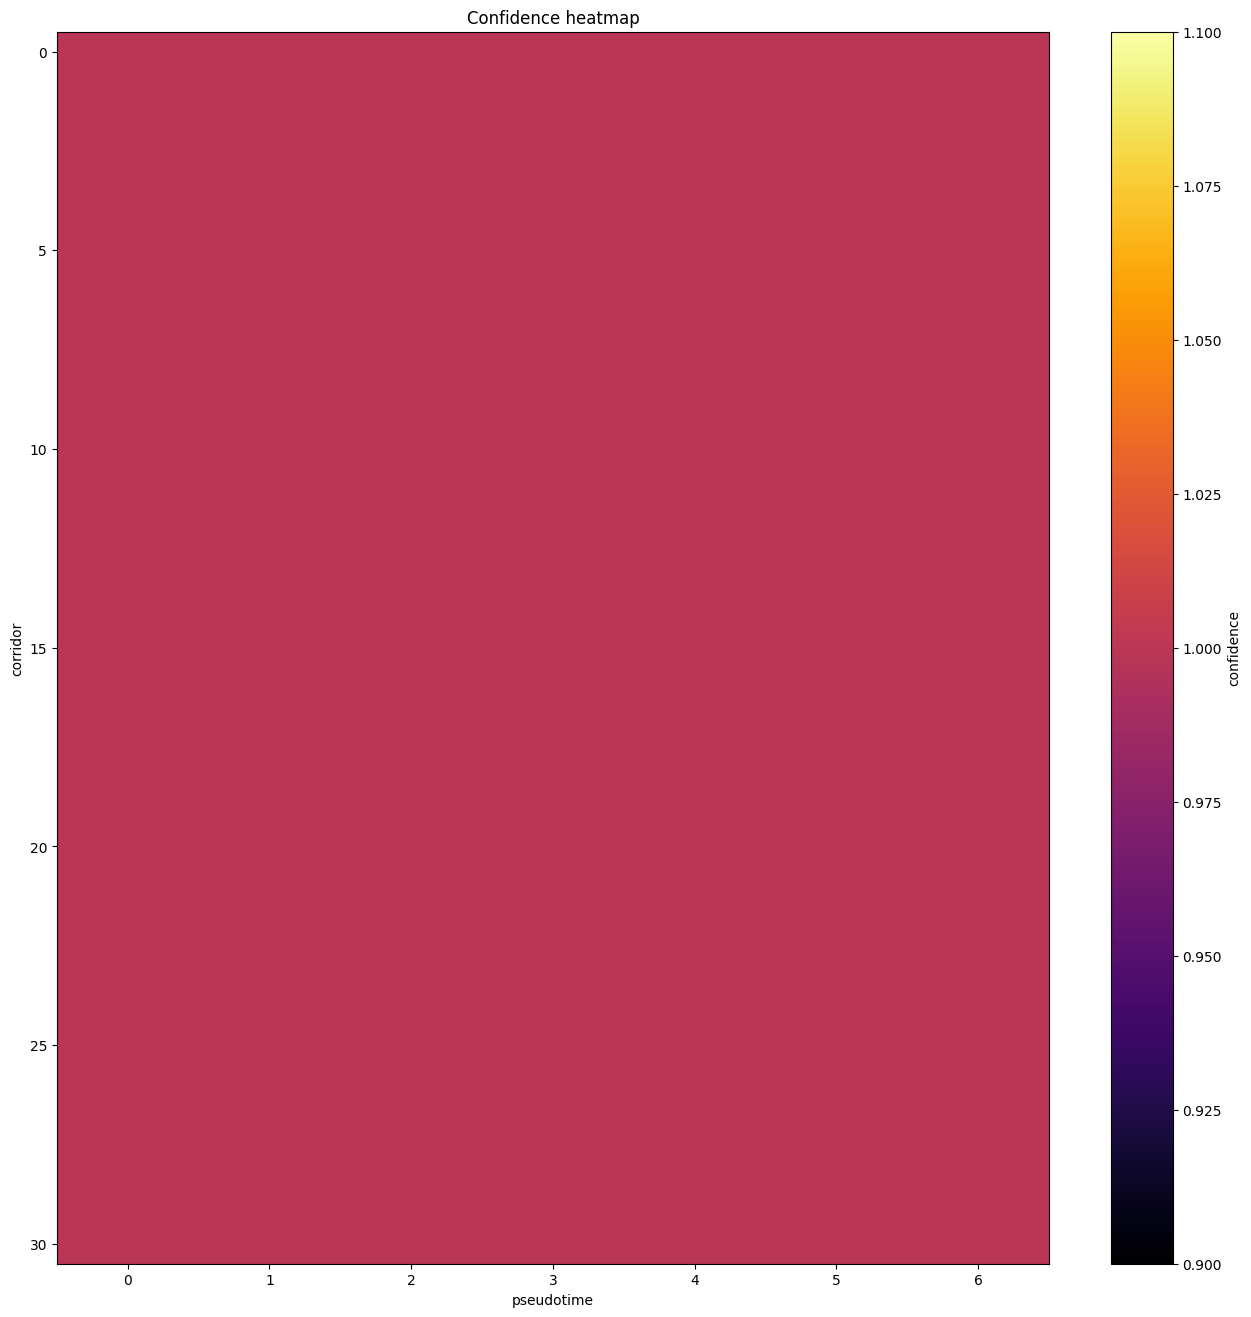

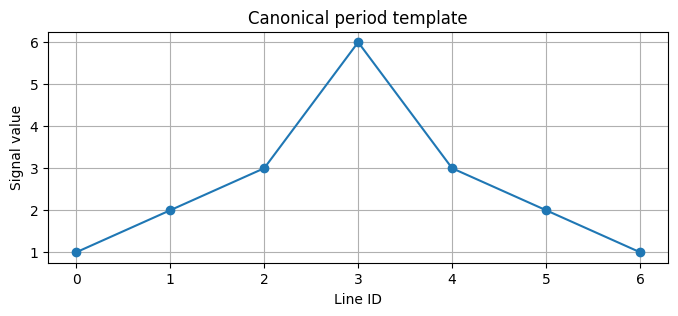

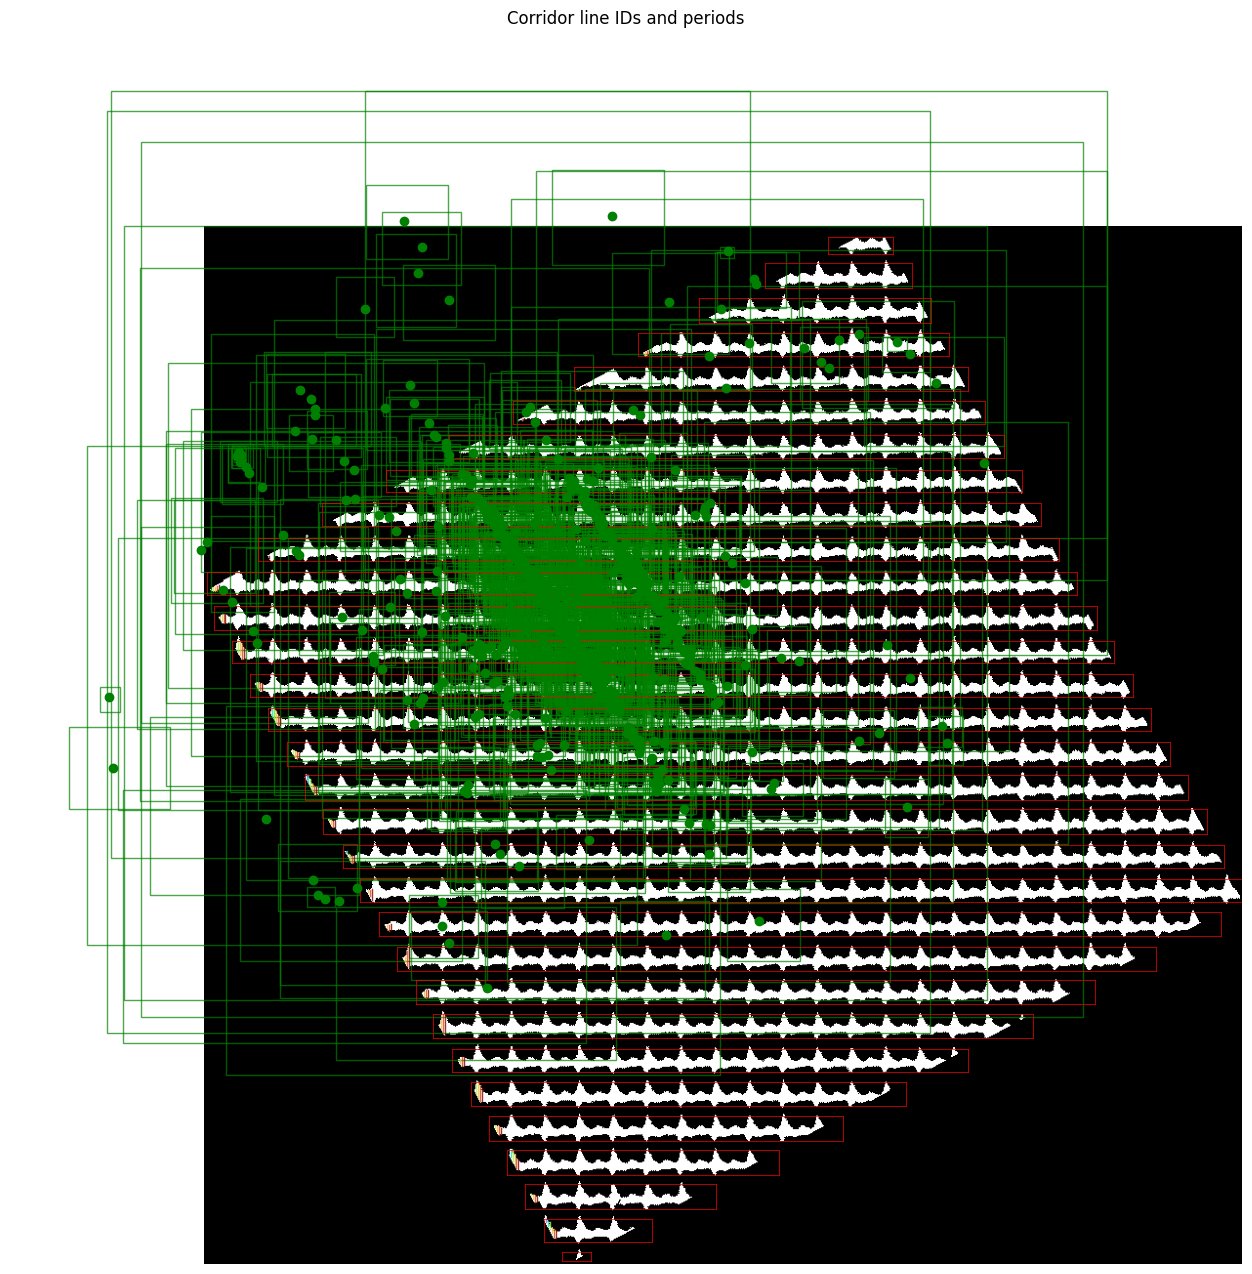

7


In [4]:
visualize_confidence(pt["corridors"])
visualize_template(pt["template"])
visualize_overlay(
    img=corr_mask,
    corridor_bbox=corridors,
    results=pt["corridors"],
    T=pt["period"],
    m=2,
    show_ids=False,
    DF=SD.dataframe,
)
print(pt['period'])

In [71]:
SD.dataframe.loc[0]["path_dapi"]

nan

C:\Users\dmitr\AppData\Local\Temp\ipykernel_26632\4222465999.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("tab20", max_rows)


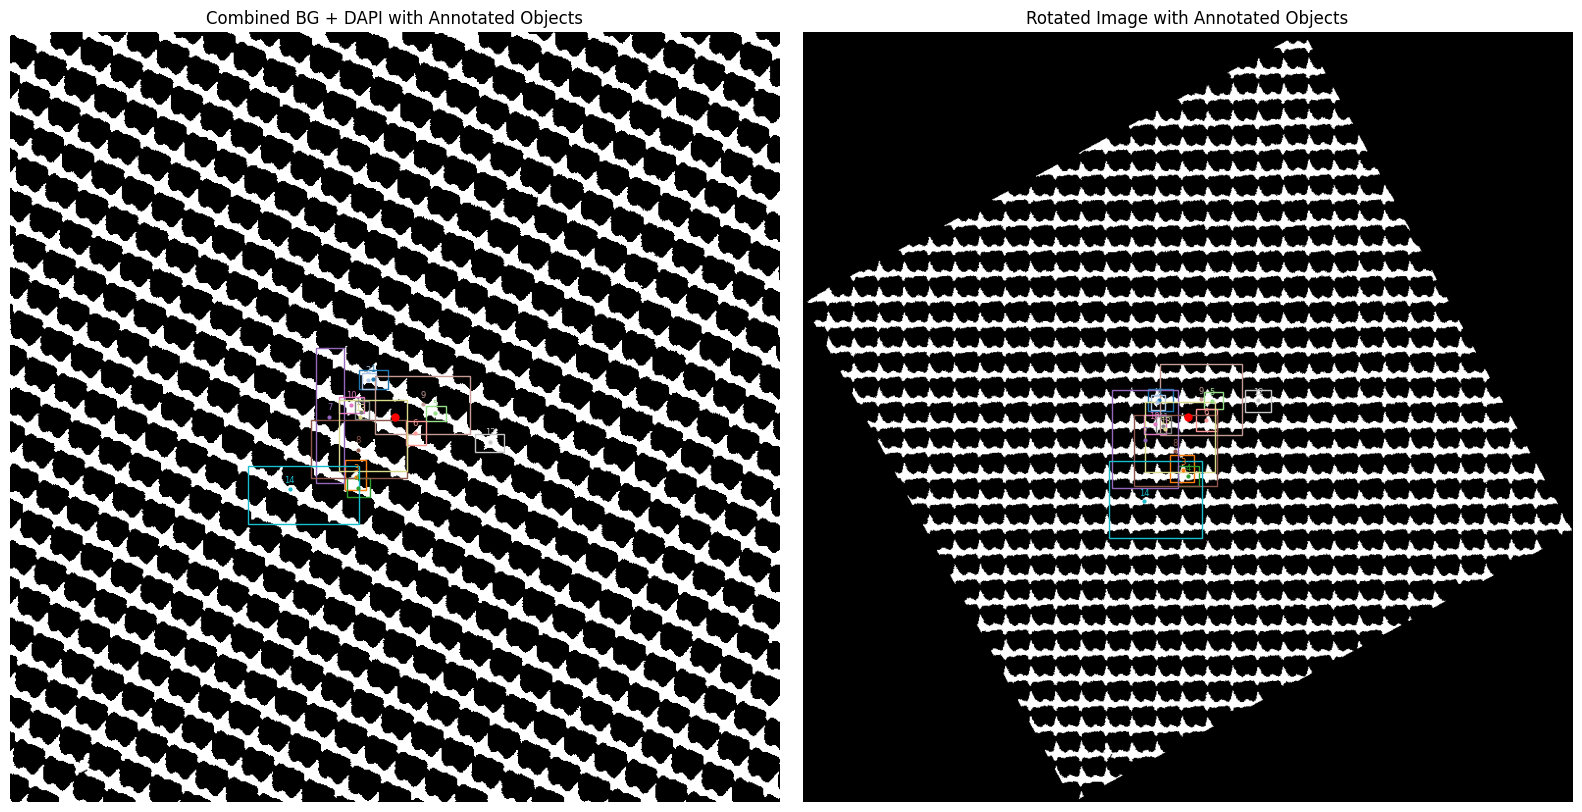

In [113]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skimage.io import imread
import matplotlib.cm as cm
from skimage import filters

def rotation_viz_with_dapi(
    BG, rotated, SD, blend_mode="add", alpha=0.5,
    max_rows=30, dot_size=3
):
    DF = SD.dataframe

    BG = BG.astype(np.float32)
    RW, RH = rotated.shape[:2]
    cry = (RW - 1) / 2
    crx = (RH - 1) / 2

    # --- 1. Build a composite DAPI image ---
    dapi_stack = []
    for idx, row in DF.iloc[:max_rows].iterrows():
        try:
            path = row["path_dapi"]
            dapi_img = imread(path)
        except Exception as e:
            print(f"Could not read DAPI image for row {idx}: {e}")
            continue

        H, W = BG.shape[:2]
        h2, w2 = dapi_img.shape[:2]

        cy_big = (H - 1) / 2
        cx_big = (W - 1) / 2

        cy_small = (h2 - 1) / 2
        cx_small = (w2 - 1) / 2

        x0 = int(round(cx_big - cx_small))
        y0 = int(round(cy_big - cy_small))

        canvas = np.zeros((H, W), dtype=float)
        #canvas = np.zeros((H, W, 2), dtype=float)

        # Destination slice (big image)
        y1 = max(0, y0)
        x1 = max(0, x0)
        y2 = min(H, y0 + h2)
        x2 = min(W, x0 + w2)

        # Corresponding source slice (small image)
        sy1 = y1 - y0
        sx1 = x1 - x0
        sy2 = sy1 + (y2 - y1)
        sx2 = sx1 + (x2 - x1)

        # Write intensity
        #canvas[y1:y2, x1:x2, 0] = dapi_img[sy1:sy2, sx1:sx2]

        # Write alpha (fully opaque where image exists)
        #canvas[y1:y2, x1:x2, 1] = 1.0

        canvas[y1:y2, x1:x2] = dapi_img[sy1:sy2, sx1:sx2] /100


        if canvas.shape[:2] != BG.shape[:2]:
            raise ValueError(f"DAPI shape {canvas.shape} != BG shape {BG.shape}")

        dapi_stack.append(canvas.astype(np.float32))

    if len(dapi_stack) == 0:
        raise RuntimeError("No DAPI images could be loaded.")

    dapi_composite = np.sum(dapi_stack, axis=0)

    # --- 2. Blend BG + DAPI ---
    if blend_mode == "add":
        combined = BG.astype(np.float32) + dapi_composite
    elif blend_mode == "alpha":
        combined = (1 - alpha) * BG.astype(np.float32) + alpha * dapi_composite
    else:
        raise ValueError("blend_mode must be 'add' or 'alpha'")

    combined = np.clip(combined, 0, 255).astype(np.uint8)

    # --- 3. Plot setup ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(combined, cmap="gray")
    axes[0].set_title("Combined BG + DAPI with Annotated Objects")
    axes[0].axis("off")

    axes[1].imshow(rotated, cmap="gray")
    axes[1].set_title("Rotated Image with Annotated Objects")
    axes[1].axis("off")

    # --- 5. Colormap for unique tint per object ---
    colormap = cm.get_cmap("tab20", max_rows)

    # --- 6. Plot each object ---
    for row_index, (idx, row) in enumerate(DF.iloc[:max_rows].iterrows()):

        color = colormap(row_index)  # unique RGBA color

        # Original coords
        x_c = (float(row["centered_center_x"])) + cx_big
        y_c = (float(row["centered_center_y"])) + cy_big

        x_min = float(row["centered_bbox_min_x"]) + cx_big
        y_min = float(row["centered_bbox_min_y"]) + cy_big
        x_max = float(row["centered_bbox_max_x"]) + cx_big
        y_max = float(row["centered_bbox_max_y"]) + cy_big

        # Draw original
        axes[0].plot(x_c, y_c, marker='o', markersize=dot_size, color=color)

        axes[0].text(
        x_c, y_c - 5,            
        f"{idx}",                
        color=color,           
        fontsize=6,
        ha="center", va="bottom"
)
        rect = Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1,
            edgecolor=color,
            facecolor='none'
        )
        axes[0].add_patch(rect)

        # Rotated coords
        x_rot_c = row["center_rot_x"] + crx
        y_rot_c = row["center_rot_y"] + cry

        x_min_rot = row["bbox_rot_min_x"] + crx
        y_min_rot = row["bbox_rot_min_y"] + cry
        x_max_rot = row["bbox_rot_max_x"] + crx
        y_max_rot = row["bbox_rot_max_y"] + cry

        # Draw rotated
        axes[1].plot(x_rot_c, y_rot_c, marker='o', markersize=dot_size, color=color)

        axes[1].text(
        x_rot_c, y_rot_c - 5,             # position (slightly above the point)
        f"{idx}",                 # text label – here using the row index
        color=color,              # same tint as the object
        fontsize=6,
        ha="center", va="bottom"
)
        
        rect = Rectangle(
            (x_min_rot, y_min_rot),
            x_max_rot - x_min_rot,
            y_max_rot - y_min_rot,
            linewidth=1,
            edgecolor=color,
            facecolor='none'
        )
        axes[1].add_patch(rect)

    axes[0].plot(cx_big, cy_big, markersize=5, color='red',  marker='o')
    axes[1].plot(crx, cry, markersize=5, color='red', marker='o')
    plt.tight_layout()
    plt.show()

BG = r'..\Chip_1462_1_real\obj0001_stainbackground_real.tiff'
BG_big = r'c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\test_1462.tif'
BG = imread(BG)

BG_big = imread(BG_big).astype(np.float32)
BG_big = np.dot(BG_big[..., :3], [0.2126, 0.7152, 0.0722])

rotation_viz_with_dapi(
    BG_big,
    rotated=corr_mask,
    SD=SD,
    blend_mode="add",
    alpha=0.6,
    max_rows=15,
    dot_size=2
)